In [1]:
from IPython.display import display 

import base64
import json
import requests
from datetime import datetime, timedelta
from tqdm import tqdm

import pandas as pd 
pd.set_option('display.float_format', '{:.00f}'.format)

import os 
import numpy as np
import ast
from sympy import symbols, solve, lambdify

In [2]:
import sys
from pathlib import Path

try:
    # Works in Python scripts
    helper_path = Path(__file__).resolve().parent.parent / "helper"
except NameError:
    # Works in Jupyter notebooks
    helper_path = Path().resolve().parent / "helper"

sys.path.insert(0, str(helper_path))

# Now import your modules
from config_GAM2025 import gam_info

from security_config import emplifi_key
from functions import execute_sql_query
import test_functions

In [3]:
platformID = 'TTK'

# country
cols = ['PlaceID',	'TikTok Codes', gam_info['population_column']]
country_codes = pd.read_excel(f"../../{gam_info['lookup_file']}", 
                              sheet_name='CountryID', usecols=cols, keep_default_na=False )

# service
cols = ['ServiceID', 'Lumen']
service_codes = pd.read_excel(f"../../{gam_info['lookup_file']}", 
                              sheet_name='ServiceID', usecols=cols, keep_default_na=False )

# week 
week_tester = pd.read_excel(f"../../{gam_info['lookup_file']}", 
                            sheet_name='GAM Period', keep_default_na=False)

week_tester['w/c'] = pd.to_datetime(week_tester['w/c'])
week_tester['week_ending'] = pd.to_datetime(week_tester['week_ending'])

# social media accounts
dtype_dict = {'Channel ID': 'str',
              'Linked FB Account': 'str'}
socialmedia_accounts = pd.read_excel(f"../../{gam_info['lookup_file']}", dtype=dtype_dict,
                                     sheet_name='Social Media Accounts new', keep_default_na=False)

socialmedia_accounts = socialmedia_accounts[(socialmedia_accounts['PlatformID'] == platformID)
                                            & 
                                            (socialmedia_accounts['Status'] == 'active')]
socialmedia_accounts = socialmedia_accounts.rename(columns={'Excluding UK': 'Channel Group'})

channel_ids = socialmedia_accounts['Channel ID'].unique().tolist()
formatted_channel_ids = ', '.join(f"'{channel_id}'" for channel_id in channel_ids)
socialmedia_accounts.sample()

,PlatformID,Status,Comment,Channel ID,Channel Name,Service,ServiceID,Channel Group,Channel URL,Channel Username,Linked FB Account,Year
248,TTK,active,39 weeks country,a53907d1-2b3d-57a1-be38-cea14a04dc0f,bbcnewsindonesia,Indonesian,INO,,,,1150118096995434e+16,GAM2025


# read in 

In [4]:

dataframes = []
storage_dir = f"../data/raw/{platformID}/post_level/"
csv_files = [f for f in os.listdir(storage_dir) if f.endswith(".csv")]
for f in csv_files:
    file_path = os.path.join(storage_dir, f)
    try:
        parts = f.replace(".csv", "").split("_")
        file_timeinfo = parts[0]
        platformID = parts[1]
        profile_id = parts[2]
        week_str = parts[3]

        df = pd.read_csv(file_path)
        df["platformID"] = platformID
        df["profile_id"] = profile_id
        df["w/c"] = week_str
        
        if not df.empty:
            dataframes.append(df)
    except pd.errors.EmptyDataError:
        print(f"❌ Could not read file (empty or malformed): {f}")

# Combine all non-empty DataFrames
if dataframes:
    post_level_df = pd.concat(dataframes, ignore_index=True)
    print("✅ Combined DataFrame created.")
    display(post_level_df.head())
else:
    print("🚫 No valid data found to combine.")


✅ Combined DataFrame created.


,attachments,author,authorId,content_type,created_time,duration,id,link,media,message,...,insights_likes,insights_reach,insights_reach_engagement_rate,insights_shares,insights_video_views,insights_view_time,insights_viewers_by_country,platformID,profile_id,w/c
0,[{'image_url': 'https://p16-sign-va.tiktokcdn....,"{'id': 'a53907d1-2b3d-57a1-be38-cea14a04dc0f',...",a53907d1-2b3d-57a1-be38-cea14a04dc0f,post,2024-09-20T09:16:56+00:00,222,7416651771059113222,https://www.tiktok.com/@bbcnewsindonesia/video...,video,Bisnis sampah? Bisa? Putu Eka Darmawan memutus...,...,9161,225634,5,2043,254630,15320564,"[{'country': 'TW', 'percentage': 0.009}, {'cou...",TTK,a53907d1-2b3d-57a1-be38-cea14a04dc0f,2024-09-16
1,[{'image_url': 'https://p19-common-sign-useast...,"{'id': '746ce2b5-197a-4eb6-86d2-aa2a39a021f7',...",746ce2b5-197a-4eb6-86d2-aa2a39a021f7,post,2024-06-07T10:31:01+00:00,59,7377706930011229473,https://www.tiktok.com/@bbclearningenglish/vid...,video,🫨 Is it difficult to understand native speaker...,...,5100,83861,7,381,102410,1850285,"[{'country': 'TH', 'percentage': 0.032}, {'cou...",TTK,746ce2b5-197a-4eb6-86d2-aa2a39a021f7,2024-06-03
2,[{'image_url': 'https://p19-common-sign-useast...,"{'id': '746ce2b5-197a-4eb6-86d2-aa2a39a021f7',...",746ce2b5-197a-4eb6-86d2-aa2a39a021f7,post,2024-06-03T12:08:14+00:00,17,7376247628910169377,https://www.tiktok.com/@bbclearningenglish/vid...,video,"If you give your opinions too directly, they c...",...,1351,26187,5,56,30466,290104,"[{'country': 'JP', 'percentage': 0.023}, {'cou...",TTK,746ce2b5-197a-4eb6-86d2-aa2a39a021f7,2024-06-03
3,[{'image_url': 'https://p19-common-sign-useast...,"{'id': '746ce2b5-197a-4eb6-86d2-aa2a39a021f7',...",746ce2b5-197a-4eb6-86d2-aa2a39a021f7,post,2024-06-21T09:22:51+00:00,55,7382884557617384736,https://www.tiktok.com/@bbclearningenglish/vid...,video,🤔 What’s wrong with saying ‘I wish I had spend...,...,1245,21793,6,32,26521,406255,"[{'country': 'VN', 'percentage': 0.088}, {'cou...",TTK,746ce2b5-197a-4eb6-86d2-aa2a39a021f7,2024-06-17
4,[{'image_url': 'https://p19-common-sign-useast...,"{'id': '746ce2b5-197a-4eb6-86d2-aa2a39a021f7',...",746ce2b5-197a-4eb6-86d2-aa2a39a021f7,post,2024-06-17T10:07:57+00:00,17,7381411814308842785,https://www.tiktok.com/@bbclearningenglish/vid...,video,"Someone asks you to do something, but you don’...",...,1541,29853,5,47,35072,328708,"[{'country': 'IT', 'percentage': 0.023}, {'cou...",TTK,746ce2b5-197a-4eb6-86d2-aa2a39a021f7,2024-06-17


                              profile_id  number_of_weeks
2   2ac83179-5aa1-4b36-9a7c-a8418f72a799               52
3   34e41ced-576d-430a-b590-55d0c1d241b1               52
10  c02ca653-c3b6-4b34-b210-711e12f9eb2d               52
7   746ce2b5-197a-4eb6-86d2-aa2a39a021f7               52
5   3d596e6a-d239-434e-bb79-93e5d291b216               52
12  fbd019f7-9dcb-5f22-a0e0-86cfb49a5959               52
9   a824bd24-fa59-4039-88bf-4b152ffa2881               52
4   3c4d1098-0742-41ed-9182-f7ea05f398cd               49
11  c3390a5e-42f2-4652-99ff-b903b61d8fc7               48
8   a53907d1-2b3d-57a1-be38-cea14a04dc0f               39
1   1ea28c7a-b8c5-4e98-9c8b-456832eb4f21               36
6   54ac56ff-37ee-597e-89ec-d63de04c9df1               12
0   057b1686-d9f3-51fe-a129-5732678e609e                4


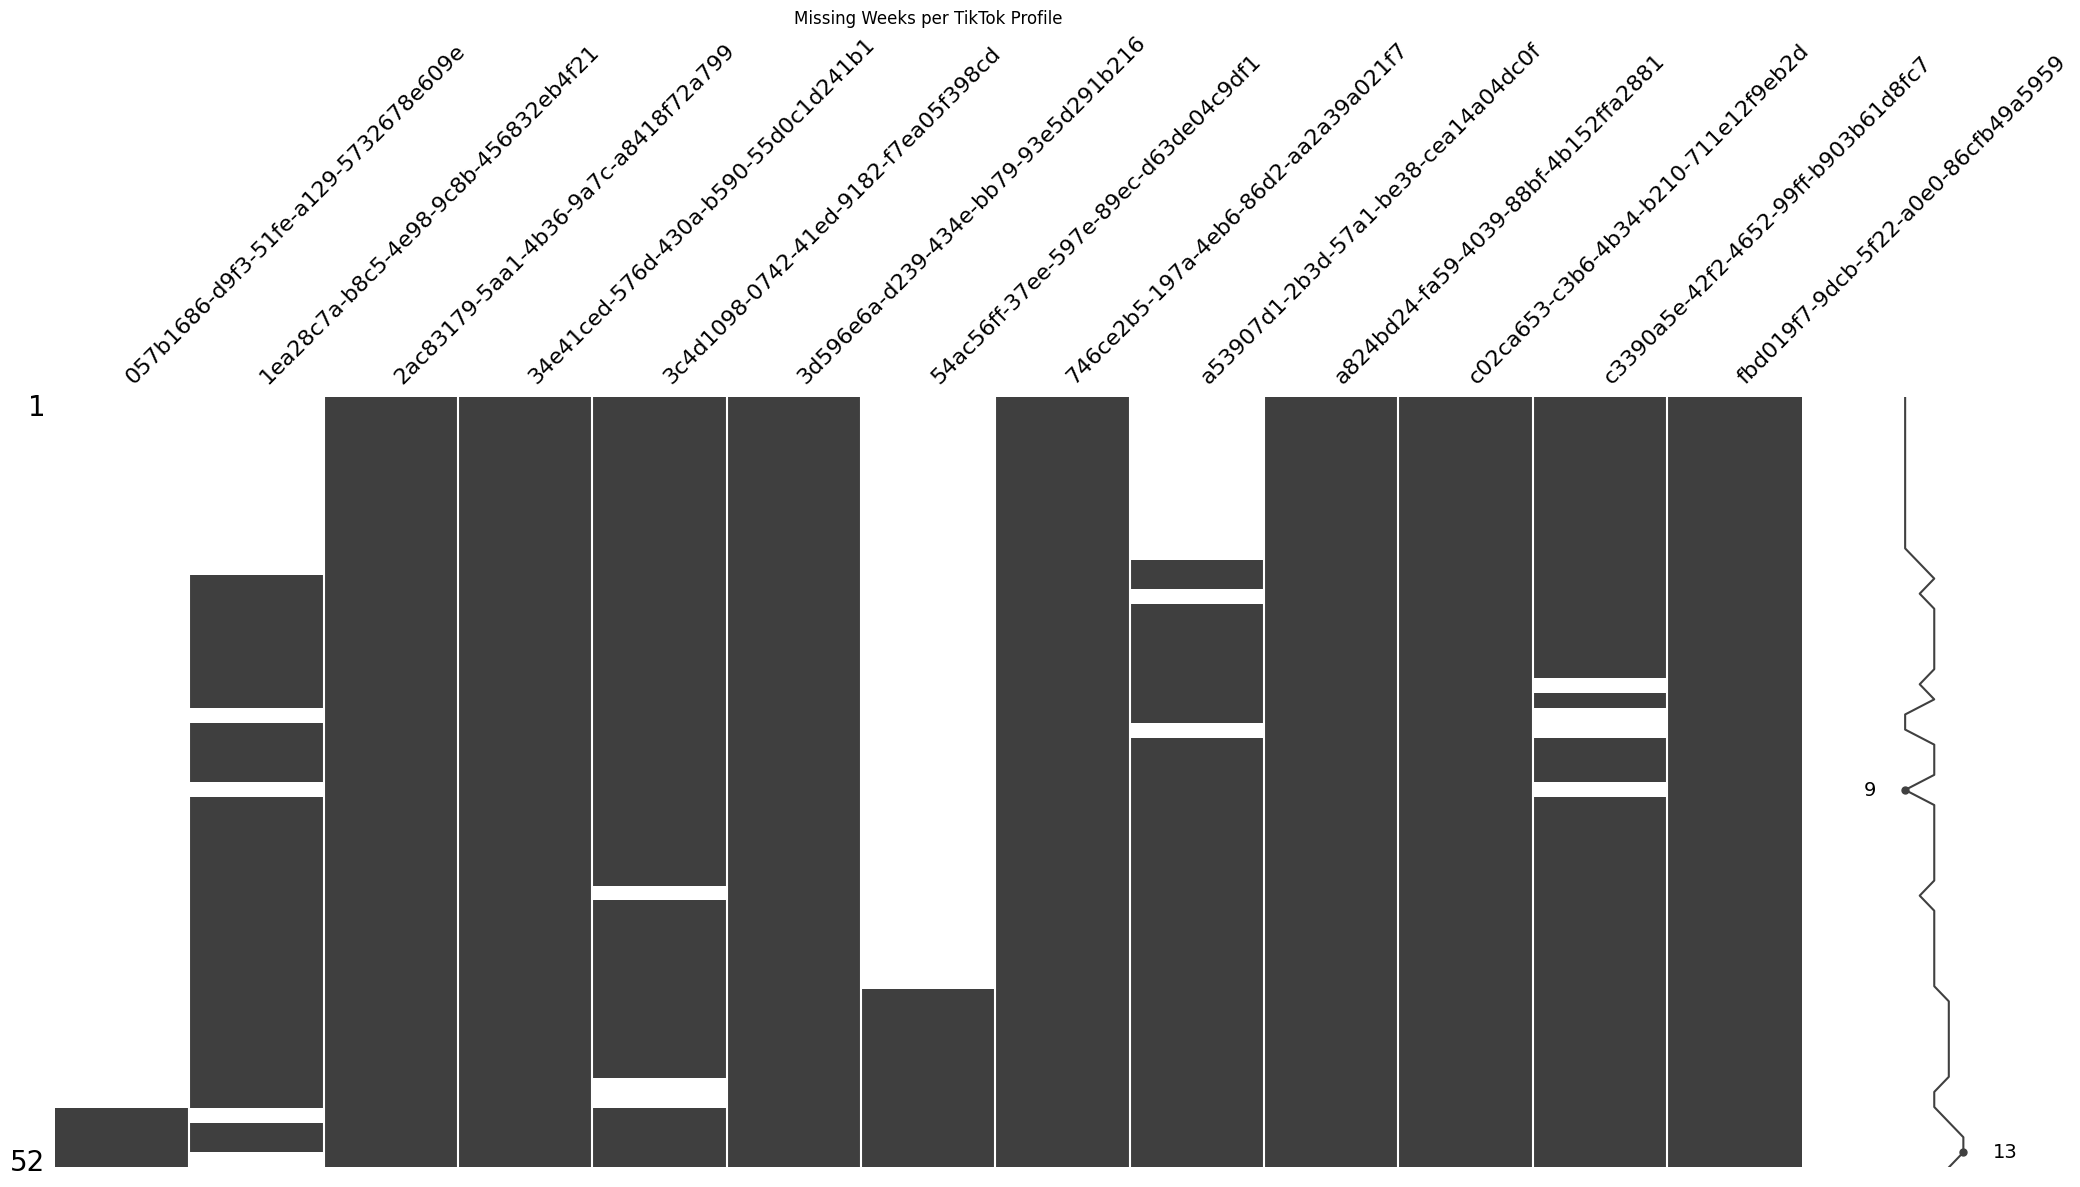

In [5]:
post_level_df = post_level_df.rename(columns={'platformID': 'PlatformID'})
# Count unique weeks per profile
week_counts = post_level_df.groupby('profile_id')['w/c'].nunique().reset_index()
week_counts.columns = ['profile_id', 'number_of_weeks']

# Optional: sort by number of weeks
week_counts = week_counts.sort_values(by='number_of_weeks', ascending=False)

# Display 
print(week_counts)

import missingno as msno
import matplotlib.pyplot as plt

# Assuming post_level_df is already loaded and contains 'profile_id' and 'w/c'
# Create a pivot table: profiles as rows, weeks as columns
pivot_df = post_level_df.pivot_table(columns='profile_id', index='w/c', aggfunc='size')

# Convert to boolean: True = data exists, False = missing
#pivot_df = pivot_df.astype(bool)

# Visualize missing data
#msno.matrix(pivot_df)
#plt.title("Missing Weeks per TikTok Profile")
#plt.show()

In [6]:

def extract_author_info(row):
    if pd.isna(row):
        return pd.Series({'id': None, 'name': None, 'url': None})

    if isinstance(row, str):
        try:
            author_dict = ast.literal_eval(row)
        except (ValueError, SyntaxError):
            return pd.Series({'id': None, 'name': None, 'url': None})
    elif isinstance(row, dict):
        author_dict = row
    else:
        return pd.Series({'id': None, 'name': None, 'url': None})

    return pd.Series({
        'id': author_dict.get('id'),
        'name': author_dict.get('name'),
        'url': author_dict.get('url')
    })

# Apply the function
post_level_df[["Channel ID", "Channel Name", "Channel URL"]] = post_level_df['author'].apply(extract_author_info)

# Views

In [7]:

minnie_cols_used = {'Date': 'w/c', #minnie has a day by day breakdown and then calculates the average
               'Profile ID': "Channel ID", # author['name'],
               'Profile name': "Channel Name", # author['url'],
               'Profile URL': "Channel URL", #author['id'],
               #'Post detail URL': 'link',
               #'Content ID': 'link', # splice out from link
               'Platform': 'PlatformID', 
               'Content type': 'content_type',
               'Media type': 'media',
               #'Title': '', # missing
               #'Description': '', # missing
               'Content': 'message',
               #'Link URL': '', #unclear
               'View on platform': 'link',
               'Engagements': 'insights_engagements',
               'Total reach': 'insights_reach', #but number is different? 
               'Video length (sec)': 'duration',
               'Video view count': 'insights_video_views',
               'Total video view time (sec)': 'insights_view_time',
               'Average time watched (sec)': 'insights_avg_time_watched',
               'Completion rate': 'insights_completion_rate',
              }

views_df = post_level_df[minnie_cols_used.values()]
views_df['link'] = views_df['link'].fillna('').astype(str)
views_df['content_id'] = views_df['link'].str.split('/').str[-1].str.split('?').str[0]
views_df.head()

/var/folders/gz/pq5c3fbj5rs1tz_5w1hycq4h0000gn/T/ipykernel_52743/3751647070.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  views_df['link'] = views_df['link'].fillna('').astype(str)
/var/folders/gz/pq5c3fbj5rs1tz_5w1hycq4h0000gn/T/ipykernel_52743/3751647070.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  views_df['content_id'] = views_df['link'].str.split('/').str[-1].str.split('?').str[0]


,w/c,Channel ID,Channel Name,Channel URL,PlatformID,content_type,media,message,link,insights_engagements,insights_reach,duration,insights_video_views,insights_view_time,insights_avg_time_watched,insights_completion_rate,content_id
0,2024-09-16,a53907d1-2b3d-57a1-be38-cea14a04dc0f,bbcnewsindonesia,https://www.tiktok.com/@bbcnewsindonesia,TTK,post,video,Bisnis sampah? Bisa? Putu Eka Darmawan memutus...,https://www.tiktok.com/@bbcnewsindonesia/video...,12027,225634,222,254630,15320564,60,0,7416651771059113222
1,2024-06-03,746ce2b5-197a-4eb6-86d2-aa2a39a021f7,BBC Learning English,https://www.tiktok.com/@bbclearningenglish,TTK,post,video,🫨 Is it difficult to understand native speaker...,https://www.tiktok.com/@bbclearningenglish/vid...,5634,83861,59,102410,1850285,18,0,7377706930011229473
2,2024-06-03,746ce2b5-197a-4eb6-86d2-aa2a39a021f7,BBC Learning English,https://www.tiktok.com/@bbclearningenglish,TTK,post,video,"If you give your opinions too directly, they c...",https://www.tiktok.com/@bbclearningenglish/vid...,1418,26187,17,30466,290104,10,0,7376247628910169377
3,2024-06-17,746ce2b5-197a-4eb6-86d2-aa2a39a021f7,BBC Learning English,https://www.tiktok.com/@bbclearningenglish,TTK,post,video,🤔 What’s wrong with saying ‘I wish I had spend...,https://www.tiktok.com/@bbclearningenglish/vid...,1303,21793,55,26521,406255,16,0,7382884557617384736
4,2024-06-17,746ce2b5-197a-4eb6-86d2-aa2a39a021f7,BBC Learning English,https://www.tiktok.com/@bbclearningenglish,TTK,post,video,"Someone asks you to do something, but you don’...",https://www.tiktok.com/@bbclearningenglish/vid...,1597,29853,17,35072,328708,10,0,7381411814308842785


In [8]:


# optional: test video length is all in seconds
print(f"number of entries: {views_df.shape}")
views_df = views_df[~views_df['insights_reach'].isna()]
print(f"number of entries that have reach: {views_df.shape}")

cols_fill_nan = ['insights_avg_time_watched', 'duration', 'insights_reach',
                 'insights_completion_rate']
views_df[cols_fill_nan] = views_df[cols_fill_nan].fillna(0)  # or any other value you'd like


number of entries: (9996, 17)
number of entries that have reach: (9996, 17)


In [9]:
# Define x and y values for each row
views_df['x1'] = 0
views_df['x2'] = views_df['insights_avg_time_watched']
views_df['x3'] = views_df['duration']
views_df['x output'] = 10

views_df['y1'] = views_df['insights_reach']
views_df['y2'] = views_df['insights_reach'] / 2
views_df['y3'] = views_df['insights_reach'] * views_df['insights_completion_rate']

x_sym, a_sym, b_sym, c_sym = symbols('x a b c')

def find_quadratic_coefficients(point1, point2, point3):
    x1, y1 = point1
    x2, y2 = point2
    x3, y3 = point3
    
    if len({x1, x2, x3}) < 3:
        return None

    y_expr = a_sym * x_sym**2 + b_sym * x_sym + c_sym

    eq1 = y_expr.subs(x_sym, x1) - y1
    eq2 = y_expr.subs(x_sym, x2) - y2
    eq3 = y_expr.subs(x_sym, x3) - y3

    solutions = solve((eq1, eq2, eq3), (a_sym, b_sym, c_sym))
    return solutions


def apply_quadratic(row):
    if row['x3'] == 0:
        return 100
    if len(set([row['x1'], row['x2'], row['x3']])) < 3:
    # Handle the case where any two x-values are the same
        return 100

    point1 = (row['x1'], row['y1'])
    point2 = (row['x2'], row['y2'])
    point3 = (row['x3'], row['y3'])
    x_val = row['x output']

    coeffs = find_quadratic_coefficients(point1, point2, point3)
    if coeffs is None:
        return np.nan

    # If all y-values are zero, use only the b coefficient
    if row['y1'] == 0 and row['y2'] == 0 and row['y3'] == 0:
        return 10 * coeffs[b_sym]

    # Otherwise, evaluate full quadratic
    y_expr = a_sym * x_sym**2 + b_sym * x_sym + c_sym
    y_val = y_expr.subs({a_sym: coeffs[a_sym], b_sym: coeffs[b_sym], c_sym: coeffs[c_sym], x_sym: x_val})
    return y_val


# Create new column with interpolated values
views_df['30sec_video_views'] = views_df.apply(apply_quadratic, axis=1).astype(float)
views_df['completed_video_views'] = views_df['insights_completion_rate'] * views_df['insights_reach']

conditions = [
    views_df['insights_reach'] == 0,
    (views_df['completed_video_views'].round(0) > views_df['30sec_video_views'].round(0)),
    views_df['insights_avg_time_watched'] <= 10,
    (views_df['insights_avg_time_watched'] > 10) & (views_df['insights_avg_time_watched'] <= 15),
    views_df['insights_reach'] < views_df['30sec_video_views'],
    views_df['duration'] == 0
]

choices = [
    views_df['insights_engagements'],
    views_df['completed_video_views'],
    views_df['insights_engagements'],
    views_df['insights_reach'] * 0.67,
    views_df['insights_reach'] * 0.799,
    views_df['insights_engagements']
]

views_df['final_video_views'] = np.select(conditions, choices, 
                                            default=views_df['30sec_video_views'])

In [10]:
views_df = views_df.merge(socialmedia_accounts[["Channel ID", "ServiceID", "Linked FB Account"]], 
                              on='Channel ID', how='left', indicator=True)
print(views_df._merge.value_counts())
views_df = views_df.drop(columns=['_merge'])

temp =views_df[views_df['content_id'] == '7353576714619931936']
(temp['completed_video_views'].round(0) > temp['30sec_video_views'].round(0)),

completed = temp['completed_video_views'].round(0).iloc[0]
thirty_sec = temp['30sec_video_views'].round(0).iloc[0]

comparison = completed > thirty_sec
print(comparison)  # Should be False

_merge
both          9996
left_only        0
right_only       0
Name: count, dtype: int64
False


In [11]:
cols = ['content_id', 'ServiceID', 'Channel ID', 'Channel Name', 'w/c', 
        'link',
        'final_video_views', 'Linked FB Account'
       ]
views_df = views_df[cols]
views_df.to_csv(f"../data/processed/{platformID}/{gam_info['file_timeinfo']}_{platformID}_views.csv",
                       index=None)


In [12]:
# YT views per viewer is missing for media action 
yt_views_per_viewer = pd.read_excel("../helper/YT views per viewer_TTKhelper.xlsx")[['w/c', 'Service', 'Value']]
yt_views_per_viewer = yt_views_per_viewer.rename(columns={'Service': 'Lumen', 'Value': 'views_per_viewer'})
yt_views_per_viewer = yt_views_per_viewer.merge(service_codes, on='Lumen', how='left').drop(columns='Lumen')
yt_views_per_viewer.sample()

,w/c,views_per_viewer,ServiceID
994,2024-06-10,1,FOA


In [13]:
views_df['w/c'] = pd.to_datetime(views_df['w/c'])
yt_views_per_viewer['w/c'] = pd.to_datetime(yt_views_per_viewer['w/c'])

views_df_yt = views_df.merge(yt_views_per_viewer, on=['ServiceID', 'w/c'], how='left', indicator=True)

matched = views_df_yt[views_df_yt['_merge'] == 'both'].drop(columns='_merge')
unmatched = views_df_yt[views_df_yt['_merge'] == 'left_only'].drop(columns=['_merge', 'views_per_viewer'])

views_per_viewer_by_service = yt_views_per_viewer.groupby(['ServiceID'])['views_per_viewer'].mean().reset_index()

matched_sec = unmatched.merge(views_per_viewer_by_service, on='ServiceID', how='left', indicator=True)
matched_sec = matched_sec[matched_sec['_merge'] == 'both'].drop(columns='_merge')

views_scaled = pd.concat([matched, matched_sec])
views_scaled['engaged_users'] = views_scaled['final_video_views']/(views_scaled['views_per_viewer']*1.14)
views_scaled.columns

Index(['content_id', 'ServiceID', 'Channel ID', 'Channel Name', 'w/c', 'link',
       'final_video_views', 'Linked FB Account', 'views_per_viewer',
       'engaged_users'],
      dtype='object')

# Country 

In [14]:
country_df = post_level_df.copy()

In [15]:

# Step 1: Parse the stringified list of country-percentage dictionaries
country_df['parsed_viewers'] = country_df['insights_viewers_by_country'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

# Step 2: Explode the parsed list into separate rows
exploded_df = country_df.explode('parsed_viewers').reset_index(drop=True)

# Step 3: Extract 'country' and 'percentage' from each dictionary
exploded_df[['country', 'percentage']] = exploded_df['parsed_viewers'].apply(
    lambda entry: pd.Series({
        'country': entry.get('country') if isinstance(entry, dict) else None,
        'percentage': entry.get('percentage') if isinstance(entry, dict) else None
    })
)

# Step 4: Drop the intermediate column
exploded_df.drop(columns=['parsed_viewers'], inplace=True)
exploded_df['country'] = exploded_df['country'].replace('Others', 'ZZ')
exploded_df['country'] = exploded_df['country'].fillna('ZZ')


In [16]:

exploded_df = exploded_df.rename(columns={'country': 'TikTok Codes'})
ttk_country = exploded_df.merge(country_codes[['TikTok Codes', 'PlaceID']], on='TikTok Codes', how='left',
                 indicator=True)

print(f"mismatches? \n{ttk_country._merge.value_counts()}")
ttk_country = ttk_country.drop(columns='_merge')

mismatches? 
_merge
both          108942
left_only          0
right_only         0
Name: count, dtype: int64


In [17]:
country_cols = ['Channel ID', 'link', 'PlaceID', 'percentage', 'w/c', 'PlatformID']
ttk_country= ttk_country[country_cols]
ttk_country.to_csv(f"../data/processed/{platformID}/{gam_info['file_timeinfo']}_{platformID}_country.csv",
                  index=None, na_rep='')

# combine views & country

In [19]:

# post_url: link
ttk_country['w/c'] = pd.to_datetime(ttk_country['w/c'])

ttk_country = ttk_country.drop(columns=['_merge'], errors='ignore')
views_scaled = views_scaled.drop(columns=['_merge'], errors='ignore')

ttk_data = ttk_country.merge(views_scaled, on=['Channel ID', 'link', 'w/c'], how='outer',
                                indicator=True)
print(f"mismatches between datasets! unreviewed yet\n {ttk_data._merge.value_counts()}")
ttk_data = ttk_data.drop(columns=['_merge'])

ttk_data['country_views'] = ttk_data["final_video_views"] * ttk_data["percentage"]
ttk_perCountry = ttk_data.groupby(['w/c', 'Channel ID', 'ServiceID',
                                'PlaceID'])['country_views'].sum().rename('country').reset_index()
ttk_global = ttk_data.groupby(['w/c', 'ServiceID','Channel ID', 
                              ])['country_views'].sum().rename('global').reset_index()

ttk_df = ttk_perCountry.merge(ttk_global, on=['ServiceID', 'w/c', 'Channel ID'], how='outer', 
                           indicator=True)
print(f"no mismatches \n {ttk_df._merge.value_counts()}")
ttk_df = ttk_df.drop(columns=['_merge'])

ttk_df['country_%'] = ttk_df['country']/ttk_df['global']
ttk_df.head()

mismatches between datasets! unreviewed yet
 _merge
both          105578
left_only       3364
right_only         0
Name: count, dtype: int64
no mismatches 
 _merge
both          9461
left_only        0
right_only       0
Name: count, dtype: int64


,w/c,Channel ID,ServiceID,PlaceID,country,global,country_%
0,2024-04-01,34e41ced-576d-430a-b590-55d0c1d241b1,AZE,AZE,255399,295621,1
1,2024-04-01,34e41ced-576d-430a-b590-55d0c1d241b1,AZE,FIN,1208,295621,0
2,2024-04-01,34e41ced-576d-430a-b590-55d0c1d241b1,AZE,FRA,1609,295621,0
3,2024-04-01,34e41ced-576d-430a-b590-55d0c1d241b1,AZE,GEO,6451,295621,0
4,2024-04-01,34e41ced-576d-430a-b590-55d0c1d241b1,AZE,GER,2085,295621,0


In [20]:
annual_ttk_country = ttk_df.groupby(['Channel ID', 'ServiceID', 'PlaceID'])['country_%'].mean().rename('AvgCountry%').reset_index()
annual_ttk_global = annual_ttk_country.groupby(['Channel ID', 'ServiceID' ])['AvgCountry%'].sum().rename('AvgGlobal%').reset_index()

annual_ttk_df = annual_ttk_country.merge(annual_ttk_global, on=['Channel ID', 'ServiceID'], how='outer', indicator=True)
print(f"no mismatches \n {annual_ttk_df._merge.value_counts()}")
annual_ttk_df = annual_ttk_df.drop(columns=['_merge'])

annual_ttk_df['country_%'] = annual_ttk_df['AvgCountry%']/annual_ttk_df['AvgGlobal%']

annual_ttk_df.to_csv(f"../data/processed/{platformID}/{gam_info['file_timeinfo']}_{platformID}_uV_country.csv",
                       index=None)

no mismatches 
 _merge
both          557
left_only       0
right_only      0
Name: count, dtype: int64


In [21]:
temp = annual_ttk_df.merge(country_codes[['PlaceID', gam_info['population_column']]],
                           on='PlaceID', how='left', indicator=True)
temp['_merge'].value_counts()
temp = temp.drop(columns='_merge')

temp = temp[temp['PlaceID'] != 'UNK']
temp_grouped = temp.groupby(['Channel ID', 'ServiceID'])['country_%'].sum().rename('sum_country_%').reset_index()

temp2 = temp.merge(temp_grouped, on=['Channel ID', 'ServiceID'], how='outer', indicator=True)
temp2._merge.value_counts()
temp2 = temp2.drop(columns='_merge')

temp2['country_%'] = temp2['country_%'] / temp2['sum_country_%']

temp3 = temp2.merge(views_scaled, on=['Channel ID', 'ServiceID'], how='outer', indicator=True)
temp3['uv_by_country'] =  temp3['engaged_users'] * temp3['country_%']


cols = ['w/c', 'PlaceID', 'ServiceID', 'Channel ID', 'uv_by_country', ]
temp3[cols].to_csv(f"../data/processed/{platformID}/{gam_info['file_timeinfo']}_{platformID}_uniqueViewer_country.csv", 
                     index=None)
